## 🤖 **Implementação do Projeto**

Este notebook demonstra o passo a passo da implementação do projeto de Alarmes Inteligentes, visando utilizar Visão Computacional e Inteligência Artificial para detectar pessoas em imagens, vídeos ou webcam. Nesse contexto, serão abordadas aqui as seguintes etapas:

- ✅ 1. Importação de Bibliotecas
- ✅ 2. Download dos datasets
- ✅ 3. Leitura dos datasets
- ✅ 4. Filtragem do dataset
- ✅ 5. Testes e Avaliação de Performance do Modelo
- ✅ 6. Demonstração do Modelo
- ✅ 7. Implementação do Alerta

#### 📚 **1. Importação de bibliotecas**

🛠️
Para essa notebook, serão necessárias bibliotecas para processamento de imagens, visualização e manipulação de Sistema Operacional, a fim de permitir operações dentro do dataset, além da biblioteca que será utilizada para baixar o dataset.
🧩

In [1]:
import os # operações de arquivos e diretórios
import kagglehub # download de datasets do Kaggle
from pycocotools.coco import COCO # manipulação de datasets no formato COCO
from ultralytics import YOLO # treinamento e avaliação de modelos de detecção de objetos
import json # formatação de arquivos json
from pycocotools.cocoeval import COCOeval # avaliação de modelos
import cv2 # processamento de imagens e visão computacional
import matplotlib.pyplot as plt # visualização de imagens e gráficos
import random # geração de valores aleatórios
import requests # geração de requisições HTTP
from IPython.display import Image # exibição de imagens em notebooks Jupyter

c:\Users\pietr\Documents\mackenzie\7_semestre\comp_visual\proj_ia_alarmes_inteligentes\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### ⬇️ **2. Download dos datasets**

📥
Nessa seção, utilizando a biblioteca Kagglehub, o dataset que será utilizado será baixado através do Kaggle. Foi a forma selecionada para download por possuir uma performance melhor, já que, por ser um dataset muito grande, tende a demorar mais tempo.

⚠️ **Atenção:** Ao executar a célula abaixo, o dataset será baixado no diretório da sua máquina, pesando em torno de 1.65GB. Caso não queira ocupar esse espaço de memória em seu computador, é recomendado que a célula abaixo não seja executada. 

Caso queira remover os arquivos que foram baixados no kaggle, **navegue até o diretório** mapeado na célula abaixo e **remova os arquivos**.
📦

In [2]:
# Realiza o download do dataset do Kaggle
kaggle_path = kagglehub.dataset_download("mathlouren/projeto-ia-dados")

#### 📖 **3. Leitura dos Datasets**

🔎
Para leitura do dataset, será utilizada a biblioteca pycocotools, que lerá as anotações (características e classificações da imagem) do dataset a partir do caminho gerado no download. Para isso, será inicializado um objeto COCO para leitura do json com as annotations.
🧠

🗺️
**Mapeamento de caminhos**
🗂️

In [3]:
# Caminhos para os ficheiros 
ann_file = kaggle_path + '\\annotations_trainval2017\\annotations\\instances_val2017.json'
img_dir = kaggle_path +'\\val2017\\val2017'

In [9]:
print("Arquivos dentro da pasta raiz do dataset:")
print(os.listdir(kaggle_path))

print("\nArquivos dentro da pasta img_dir (val2017):")
try:
    print(os.listdir(img_dir)[:5]) 
except FileNotFoundError:
    print("A pasta img_dir não foi encontrada nesse caminho!")

Arquivos dentro da pasta raiz do dataset:
['annotations_trainval2017', 'val2017']

Arquivos dentro da pasta img_dir (val2017):
['000000000139.jpg', '000000000285.jpg', '000000000632.jpg', '000000000724.jpg', '000000000776.jpg']


⚙️
**Inicialização do Objeto COCO**
🤖

In [10]:
# Inicializa o objeto COCO para ler as anotações
coco = COCO(ann_file)

loading annotations into memory...
Done (t=0.29s)
creating index...
index created!


#### 🧹 **4. Filtragem do Dataset**

🎯
Nessa seção, o dataset lido pelo objeto COCO será filtrado, em que sejam obtidas somente aqueles com a classe person. A filtragem é feita a partir de operações do próprio objeto COCO. 
✅

⚠️
Em paralelo, a fim de não impactar na performance do modelo, o arquivo de annotations também deve ser filtrado, de modo que as outras classes não prejudiquem a avaliação de performance do modelo.
✅

In [27]:
# Obtém o ID da categoria "person" (pessoa) no dataset COCO
category_id = coco.getCatIds(catNms=['person'])

# Obtém os IDs das imagens que contêm a categoria "person"
image_ids = coco.getImgIds(catIds=category_id)

#### 📊 **5. Avaliação de Performance do Modelo**

📈
Com o dataset filtrado, parte-se para a execução do modelo YOLOv8 sob as imagens do dataset para a detecção de pessoas. Após a comparação, o modelo será avaliado com base no que foi detectado. Para isso, serão utilizadas algumas métricas, sendo elas:

- **IoU (Intersection Over Union):** Calculada para cada imagem, calculando a sobreposição da detecção prevista em relação a detecção verdadeira sinalizada pelas annotations.✅

- **mAP (Mean Average Precision):** A precisão média das detecções realizadas calculadas através do IoU. Podendo ser realizada apenas com a meta de 50% (mais generosa) ou de 50% a 95% (mais rígida).✅

- **Precisão:** Proporção de previsões positivas em relação às previsões positivas do modelo.✅

- **Recall:** Mede a capacidade do modelo de encontrar casos positivos dentro de um conjunto de dados.
✅

🤔 Para isso, a performance será avaliada através do COCOeval, disponibilizado pela biblioteca COCO.

🤖 **Carregamento do Modelo**

In [28]:
yolo = YOLO('yolov8n.pt') # Carrega o modelo pré-treinado YOLOv8n

In [36]:
# Preparação de um dataset YOLO para validação usando o conjunto COCO val
# O YOLO val() espera imagens em um diretório 'images/...' e labels em 'labels/...'
# Nós iremos criar esses arquivos aqui a partir das anotações COCO existentes.

yolo_dataset_root = os.path.join(os.getcwd(), "yolo_dataset")
yolo_val_images = os.path.join(yolo_dataset_root, "images", "val2017")
yolo_val_labels = os.path.join(yolo_dataset_root, "labels", "val2017")

os.makedirs(yolo_val_images, exist_ok=True)
os.makedirs(yolo_val_labels, exist_ok=True)

# Cria hard links para as imagens (não faz cópia dos dados se o filesystem permitir)
if not os.listdir(yolo_val_images):
    print('Criando links para imagens de validação YOLO...')
    for img_info in coco.loadImgs(image_ids):
        src = os.path.join(img_dir, img_info['file_name'])
        dst = os.path.join(yolo_val_images, img_info['file_name'])
        if not os.path.exists(dst):
            try:
                os.link(src, dst)
            except OSError:
                from shutil import copy2
                copy2(src, dst)
    print('Imagens de validação preparadas em:', yolo_val_images)

# Converte as annotations COCO de pessoa para labels YOLO
anns_by_img = {}
for ann in coco.loadAnns(coco.getAnnIds(imgIds=image_ids, catIds=category_id, iscrowd=None)):
    anns_by_img.setdefault(ann['image_id'], []).append(ann)

for img_id in image_ids:
    img_info = coco.loadImgs(img_id)[0]
    label_path = os.path.join(yolo_val_labels, os.path.splitext(img_info['file_name'])[0] + '.txt')
    lines = []
    for ann in anns_by_img.get(img_id, []):
        x, y, w, h = ann['bbox']
        xc = (x + w / 2) / img_info['width']
        yc = (y + h / 2) / img_info['height']
        w_norm = w / img_info['width']
        h_norm = h / img_info['height']
        lines.append(f"0 {xc:.6f} {yc:.6f} {w_norm:.6f} {h_norm:.6f}")
    with open(label_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))

# Cria o arquivo de dados YAML para validação
yaml_path = os.path.join(yolo_dataset_root, 'coco_person.yaml')
with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write('path: "' + yolo_dataset_root.replace('\\', '/') + '"\n')
    f.write('train: "images/val2017"\n')
    f.write('val: "images/val2017"\n')
    f.write('nc: 1\n')
    f.write('names: ["person"]\n')

print('Arquivo de dados YAML criado em:', yaml_path)
print('Executando yolo.val()...')
metrics = yolo.val(data=yaml_path)
print(metrics)

Arquivo de dados YAML criado em: c:\Users\pietr\Documents\mackenzie\7_semestre\comp_visual\proj_ia_alarmes_inteligentes\yolo_dataset\coco_person.yaml
Executando yolo.val()...
Ultralytics 8.4.43  Python-3.11.9 torch-2.11.0+cpu CPU (AMD Ryzen 5 5600X 6-Core Processor)
val: Fast image access  (ping: 0.10.0 ms, read: 1221.2273.2 MB/s, size: 182.9 KB)
val: Scanning C:\Users\pietr\Documents\mackenzie\7_semestre\comp_visual\proj_ia_alarmes_inteligentes\yolo_dataset\labels\val2017... 2693 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2693/2693 939.7it/s 2.9s.0ss
val: New cache created: C:\Users\pietr\Documents\mackenzie\7_semestre\comp_visual\proj_ia_alarmes_inteligentes\yolo_dataset\labels\val2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 169/169 1.3it/s 2:110.7ss
                   all       2693      11004      0.786      0.646      0.732      0.501
                person       2693      11004      0.786      0.64

#### 🖼️ **6. Demonstração do Modelo**

🎬
Abaixo, estão algumas imagens para fins de comparação, comparando o que o modelo YOLO detectou com o que era esperado.
🧭

 --- Gerando demonstração para 4 imagens --- 


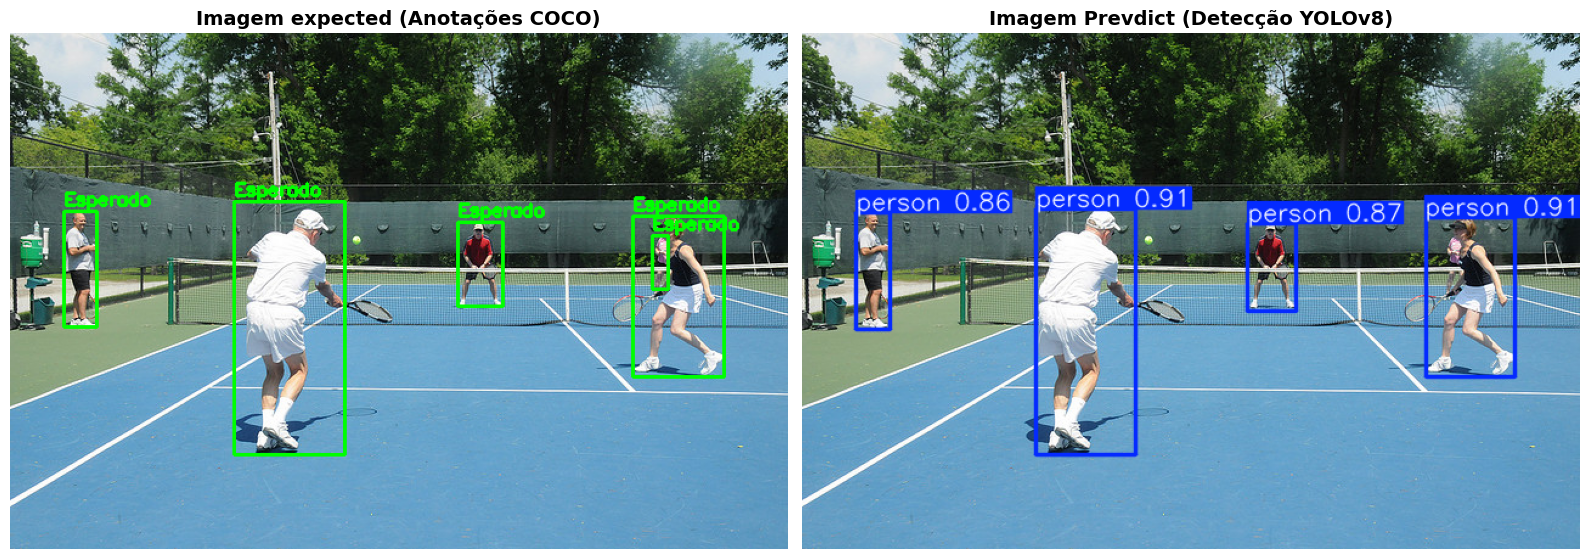

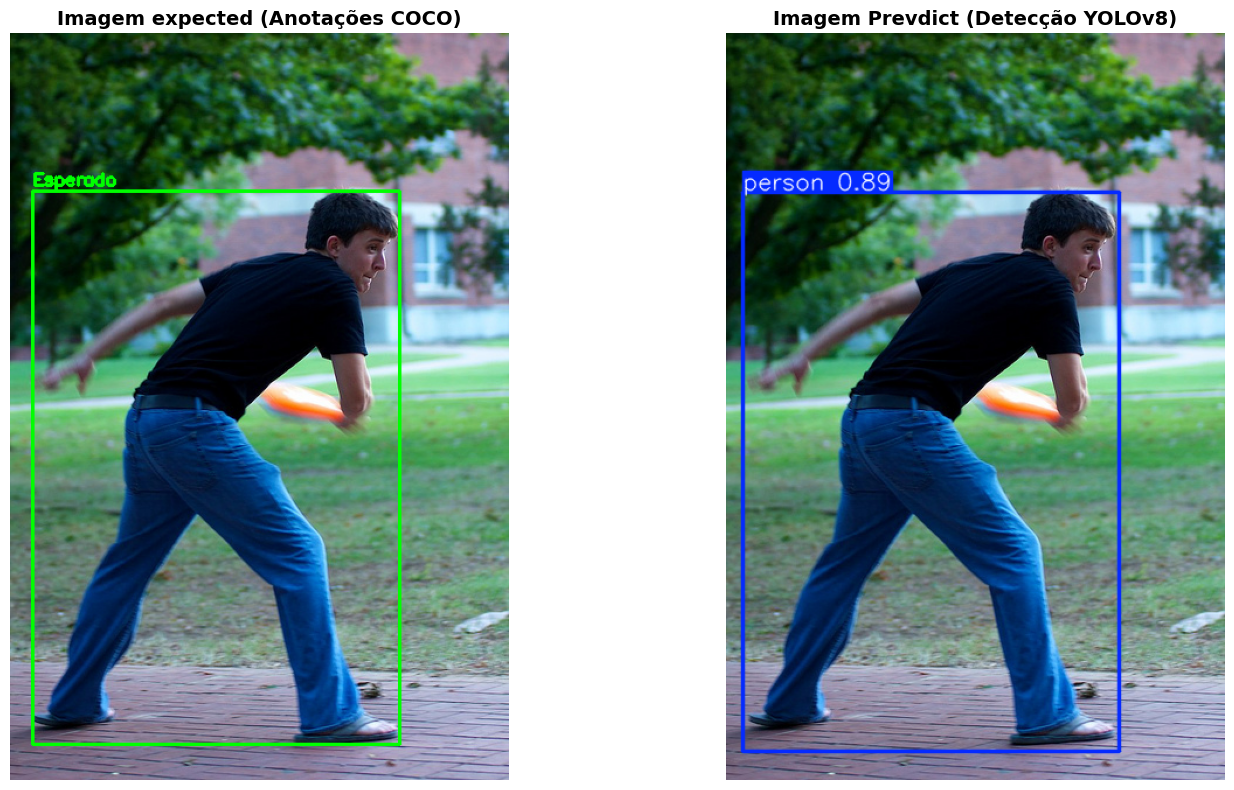

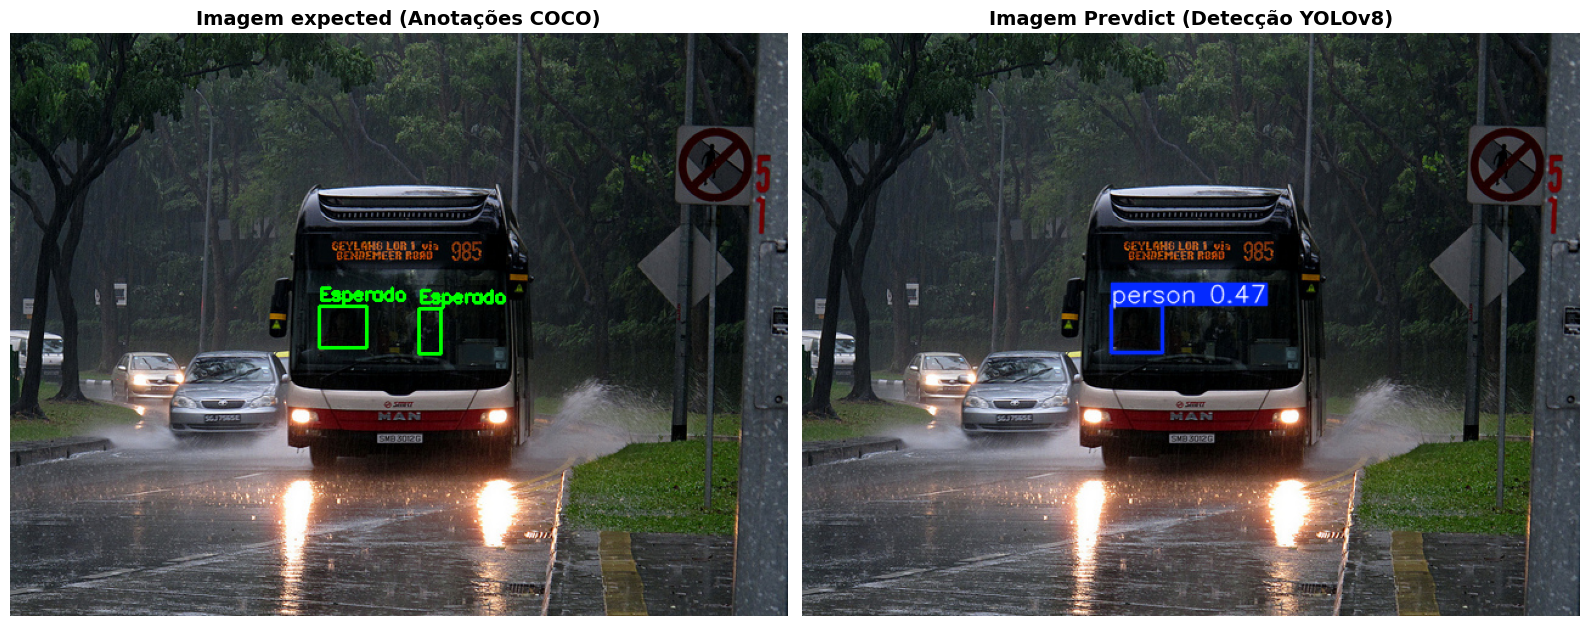

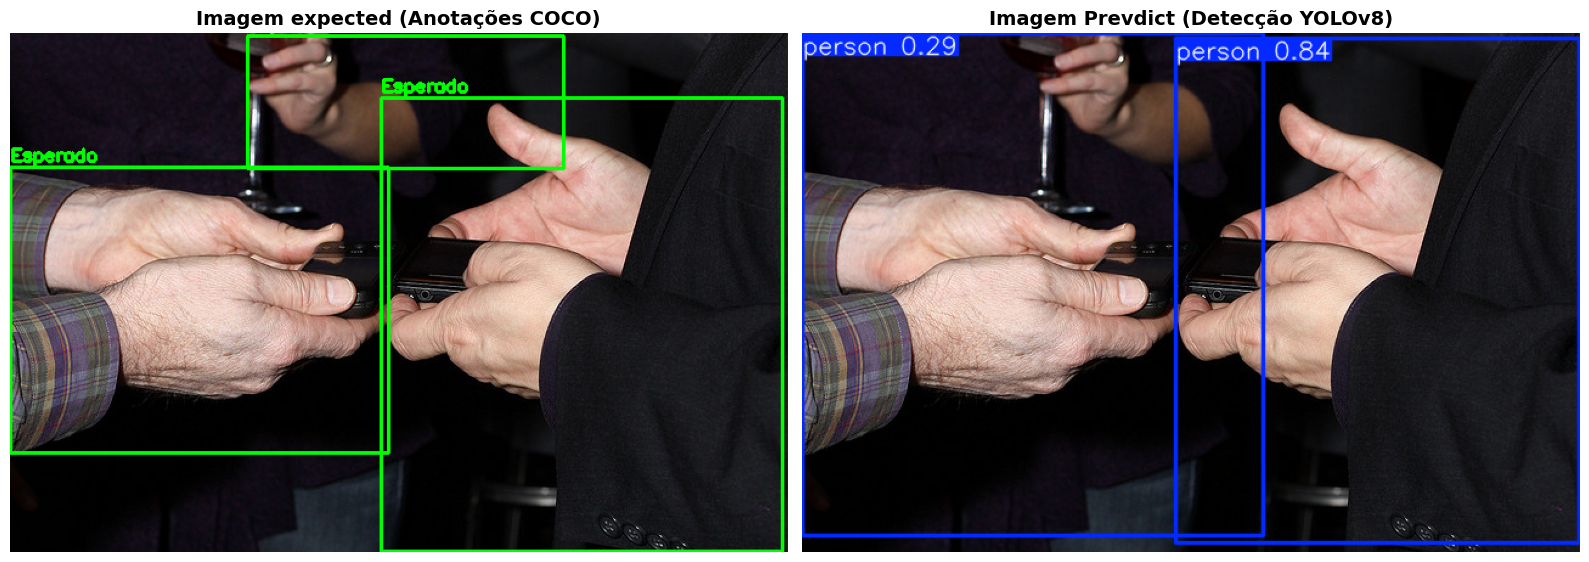

In [25]:
# Define a quantidade de exemplos que vão ser mostrados
num_exemplos = 4

# Seleciona aleatoriamente IDs de imagens do nosso conjunto filtrado
amostras_ids = random.sample(image_ids, num_exemplos)

print(f" --- Gerando demonstração para {num_exemplos} imagens --- ")

for img_id in amostras_ids:
    # Obtém as informações da imagem no COCO
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])
    
    # Carrega a imagem original e converte de BGR para RGB (OpenCV -> Matplotlib)
    img_original = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    
    # Imagem esperada do COCO
    img_expected = img_rgb.copy()
    
    # Carrega as anotações exclusivas da categoria 'person' para esta imagem
    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=[category_id], iscrowd=None)
    anns = coco.loadAnns(ann_ids)
    
    for ann in anns:
        # Extrai as coordenadas no formato COCO
        x, y, w, h = [int(v) for v in ann['bbox']]
        
        # Desenha o retângulo verde para representar o que o modelo deveria encontrar
        cv2.rectangle(img_expected, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img_expected, 'Esperado', (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Realiza a predição (detecção do YOLO)
    resultados = yolo(img_path, classes=[0], verbose=False)
    
    # Utilizando o .plot do YOLO (desenha as caixas, labels e porcentagem)
    img_prevdict_bgr = resultados[0].plot()
    img_prevdict_rgb = cv2.cvtColor(img_prevdict_bgr, cv2.COLOR_RGB2BGR)

    # Cria uma figura com 1 linha e 2 colunas
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plota a imagem com as anotações do dataset
    axes[0].imshow(img_expected)
    axes[0].set_title("Imagem expected (Anotações COCO)", fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Plota a imagem com as detecções do modelo
    axes[1].imshow(img_prevdict_rgb)
    axes[1].set_title("Imagem Prevdict (Detecção YOLOv8)", fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # Ajusta o layout para não sobrepor títulos e exibe o plot
    plt.tight_layout()
    plt.show()

🏁
Com base nas imagens demonstradas, portanto, prova-se que o modelo funciona e está alinhado com o esperado pelas annotations do dataset. No entando, houveram alguns casos em que as pessoas não foram detectadas, por estarem muito distantes na imagem e por consequência possuírem uma baixa precisão na detecção.
📌

#### 🚨 **7. Implementação do Alerta**

🧸
Validando a qualidade do modelo YOLOv8, parte-se para a implementação dos alertas, que funcionará da seguinte forma:

- Observa os frames de uma webcam, por exemplo.

- Caso detecte uma pessoa com 60% de previsão
    - Será enviado um alerta por mensagem, indicando a detecção e a imagem no qual ela ocorreu.
    - Aguardar alguns segundos até a próxima detecção

Para o envio de mensagens, será utilizada a API do Telegram, que enviará o alerta através de bots.

Nesse contexto, para a implementação do alerta, serão implementados dois níveis diferentes, seguindo o mesmo algoritmo:

- Versão simplificada que detecta uma pessoa em imagem, e se detectar, envia o alerta.

- Versão mais complexa, que faz o mesmo processo com a Webcam em tempo real.
👼

⚠️ **Atenção:** Para garantir o funcionamento da implementação, é necessária a criação de um **Telegram bot**. Para isso, siga o tutorial presente em [2_7_tutorial_criacao_bots.md](2_7_tutorial_criacao_bots.md)

🤖 Assim que o robô for criado, **preencha as variáveis abaixo**

In [11]:
# Configurações do bot

# preencher valores abaixo conforme a criação do bot
TOKEN = "8721584717:AAEXc5auScNfWrf1QCpJziyin-zPk1HsVRI"
CHAT_ID = "-5118151505"

url = f"https://api.telegram.org/bot{TOKEN}/sendPhoto"
msg = "ALERTA! 🚨 Uma pessoa foi detectada. Veja a imagem.🖼️"

🪨
**Implementação: Versão Simplificada**
🪨

Detecção de pessoas nas imagens do dataset.

In [ ]:
try:
    print("> Iniciando Alerta (v1)...")
    alert_id_img = random.choice(image_ids) # Seleção de imagem
    alert_img_info = coco.loadImgs(alert_id_img)[0] # infos da imagem

    # caminho 
    alert_img_path = os.path.join(img_dir, alert_img_info['file_name'])

    # detecção
    alert_predict = yolo(alert_img_path, classes=[0], verbose=False)

    person_found = False
    # verifica se alguma pessoa foi detectada
    for res in alert_predict:
        predict_class = res.boxes.cls
        # se encontrar pessoa
        if 0 in predict_class:
            person_found = True

    # caso uma pessoa for detectada
    if person_found:
        print("> Pessoa detectada, enviando alerta...")
        # envio do alerta
        annotated_alert = alert_predict[0].plot() # plot na imagem
        annotated_alert_bgr = cv2.cvtColor( # desenho das bboxes
            annotated_alert, cv2.COLOR_RGB2BGR
        )

        # buffer para envio
        _, buffer = cv2.imencode('.jpg', annotated_alert_bgr)

        # PARÂMETROS REQUISIÇÃO

        files = { 
            "photo": ('imagem.jpg', buffer.tobytes())
        }

        data = {
            "chat_id": CHAT_ID,
            "caption": msg
        }

        # envio da requisição
        response = requests.post(url, data=data, files=files)
        print("> Alerta enviado.")

        print("> Mostrando imagem com alerta...")
        cv2.imshow("frame", annotated_alert_bgr)
        cv2.waitKey(2000)
except Exception as e: # captura de erros
    print("> Houve um erro durante a execução", e)
finally: # encerramento
    try:
        cv2.destroyAllWindows()
    except:
        pass

> Iniciando Alerta (v1)...
> Pessoa detectada, enviando alerta...
> Alerta enviado.
> Mostrando imagem com alerta...


: 

In [1]:
yolo.metrics()

NameError: name 'yolo' is not defined

🚀
**Implementação: Versão Final**
🚀

Detecção de pessoas através da webcam.

In [ ]:
try:
    print("> Iniciando Alerta (v1)...")
    # objeto para câmera
    print("> Acessando câmera...")
    camera = cv2.VideoCapture(0)
    run = True

    while run == True:
        print("> Lendo frame da câmera...")
        status, frame = camera.read() # lê frame da câmera

        # condição de parada
        if not status:
            run = False
            break

        small = cv2.resize(frame, (640, 360))
        cv2.imshow("preview", small)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            run = False
            break

        alert_predict = yolo(small, classes=[0], verbose=False)

        person_found = False
        for res in alert_predict: # verifica as classes 
            predict_class = res.boxes.cls
            if 0 in predict_class:
                person_found = True
                break

        if person_found:
            # envio do alerta
            print("> Pessoa detectada, enviando alerta...")
            annotated_alert = alert_predict[0].plot() # plot na imagem
            annotated_alert_bgr = cv2.cvtColor(
                annotated_alert, cv2.COLOR_RGB2BGR
            )

            _, buffer = cv2.imencode('.jpg', annotated_alert_bgr)

            # PARÂMETROS DA REQUISIÇÃO

            files = {
                "photo": ('imagem.jpg', buffer.tobytes())
            }

            data = {
                "chat_id": CHAT_ID,
                "caption": msg
            }

            # envio da requisição 
            response = requests.post(url, data=data, files=files)
            print("> Alerta enviado.")

            # mostra imagem
            print("> Mostrando imagem com alerta...")
            cv2.imshow("frame", annotated_alert_bgr)
            cv2.waitKey(2000)
            run = False # para teste, para não ficar enviando alertas sem parar
except Exception as e: # captura de erros
    print("> Houve um erro durante a execução", e)
finally: # Encerramento de janelas e liberação da câmera
    try:
        camera.release()
    except:
        pass
    try:
        cv2.destroyAllWindows()
    except:
        pass


> Iniciando Alerta (v1)...
> Acessando câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lendo frame da câmera...
> Lend

📨Com a implementação do alerta, a mensagem será encaminhada através do Telegram, como na imagem abaixo. O mesmo ocorre para as pessoas.

In [ ]:
Image('demo.jpeg')

FileNotFoundError: No such file or directory: 'demo.jpeg'

FileNotFoundError: No such file or directory: 'demo.jpeg'

<IPython.core.display.Image object>

🖼️ A partir da execução desse código, após a detecção de uma pessoa pelo modelo, um alerta é enviado através do bot através da requisição.

🏁
**Conclusão:** A partir do desenvolvimento, portanto, é possível notar o impacto do uso de Visão Computacional e Algoritmos de Inteligência Artificial na segurança, garantindo que a situação seja monitorada em tempo real através de modelos de detecção de objetos.
📌